<div style="text-align: center;">
  <h1><b>🧠 Brain Tumor Classification using EfficientNet 🏥🚀</b></h1>
  <h3><i>Deep Learning-Based Medical Image Classification System</i></h3>
</div>

<p align="center">
  <img src="10586_2024_4532_Fig3_HTML.png" width="800"/>
</p>

# **Our Details**

### ‎‧₊˚✿[My Name]✿˚ : **Mohamed Reda Ramadan Khamis**
### ‎‧₊˚✿[Phone Number]✿˚: **01554725661**

In [1]:
!pip install opendatasets

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
import os

from tqdm import tqdm
import itertools


from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, AveragePooling2D, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

np.random.seed(42)

In [ ]:
def make_dataset(path):
    data_path = path

    all_paths = []
    all_labels = []


    all_folders = os.listdir(data_path)

    for folder in all_folders:

        folder_path = os.path.join(data_path , folder)

        all_imgs = os.listdir(folder_path)

        for img in all_imgs:
            image_path = os.path.join(folder_path,img)

            all_paths.append(image_path)

            all_labels.append(folder)


    paths = pd.Series(all_paths, name = "img_path")
    labels = pd.Series(all_labels, name = "img_label")

    return pd.concat([paths, labels], axis=1)

In [3]:
import opendatasets as od
od.download ("https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Mohamed Reda
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


100%|██████████| 157M/157M [00:00<00:00, 220MB/s]


In [4]:
training_data = "/content/brain-tumor-mri-dataset/Training"

'/content/brain-tumor-mri-dataset/Training'

In [7]:
testing_data = "/content/brain-tumor-mri-dataset/Testing"
testing_data

'/content/brain-tumor-mri-dataset/Testing'

In [8]:
valid_df, test_df = train_test_split(testing_data, train_size=0.5, shuffle= True, random_state=42)

In [11]:
def make_dataset(path):
    data_path = path

    all_paths = []
    all_labels = []


    all_folders = os.listdir(data_path)

    for folder in all_folders:

        folder_path = os.path.join(data_path , folder)

        all_imgs = os.listdir(folder_path)

        for img in all_imgs:
            image_path = os.path.join(folder_path,img)

            all_paths.append(image_path)

            all_labels.append(folder)


    paths = pd.Series(all_paths, name = "img_path")
    labels = pd.Series(all_labels, name = "img_label")

    return pd.concat([paths, labels], axis=1)

from tensorflow.keras.applications.efficientnet import preprocess_input

batch_size = 16
img_size = (380, 380)

train_df = make_dataset(training_data)
test_full_df = make_dataset(testing_data)

valid_df, test_df = train_test_split(test_full_df, train_size=0.5, shuffle= True, random_state=42)

tr_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
ts_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = tr_gen.flow_from_dataframe(
    train_df,
    x_col='img_path',
    y_col='img_label',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

valid_generator = ts_gen.flow_from_dataframe(
    valid_df,
    x_col='img_path',
    y_col='img_label',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

test_generator = ts_gen.flow_from_dataframe(
    test_df,
    x_col='img_path',
    y_col='img_label',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


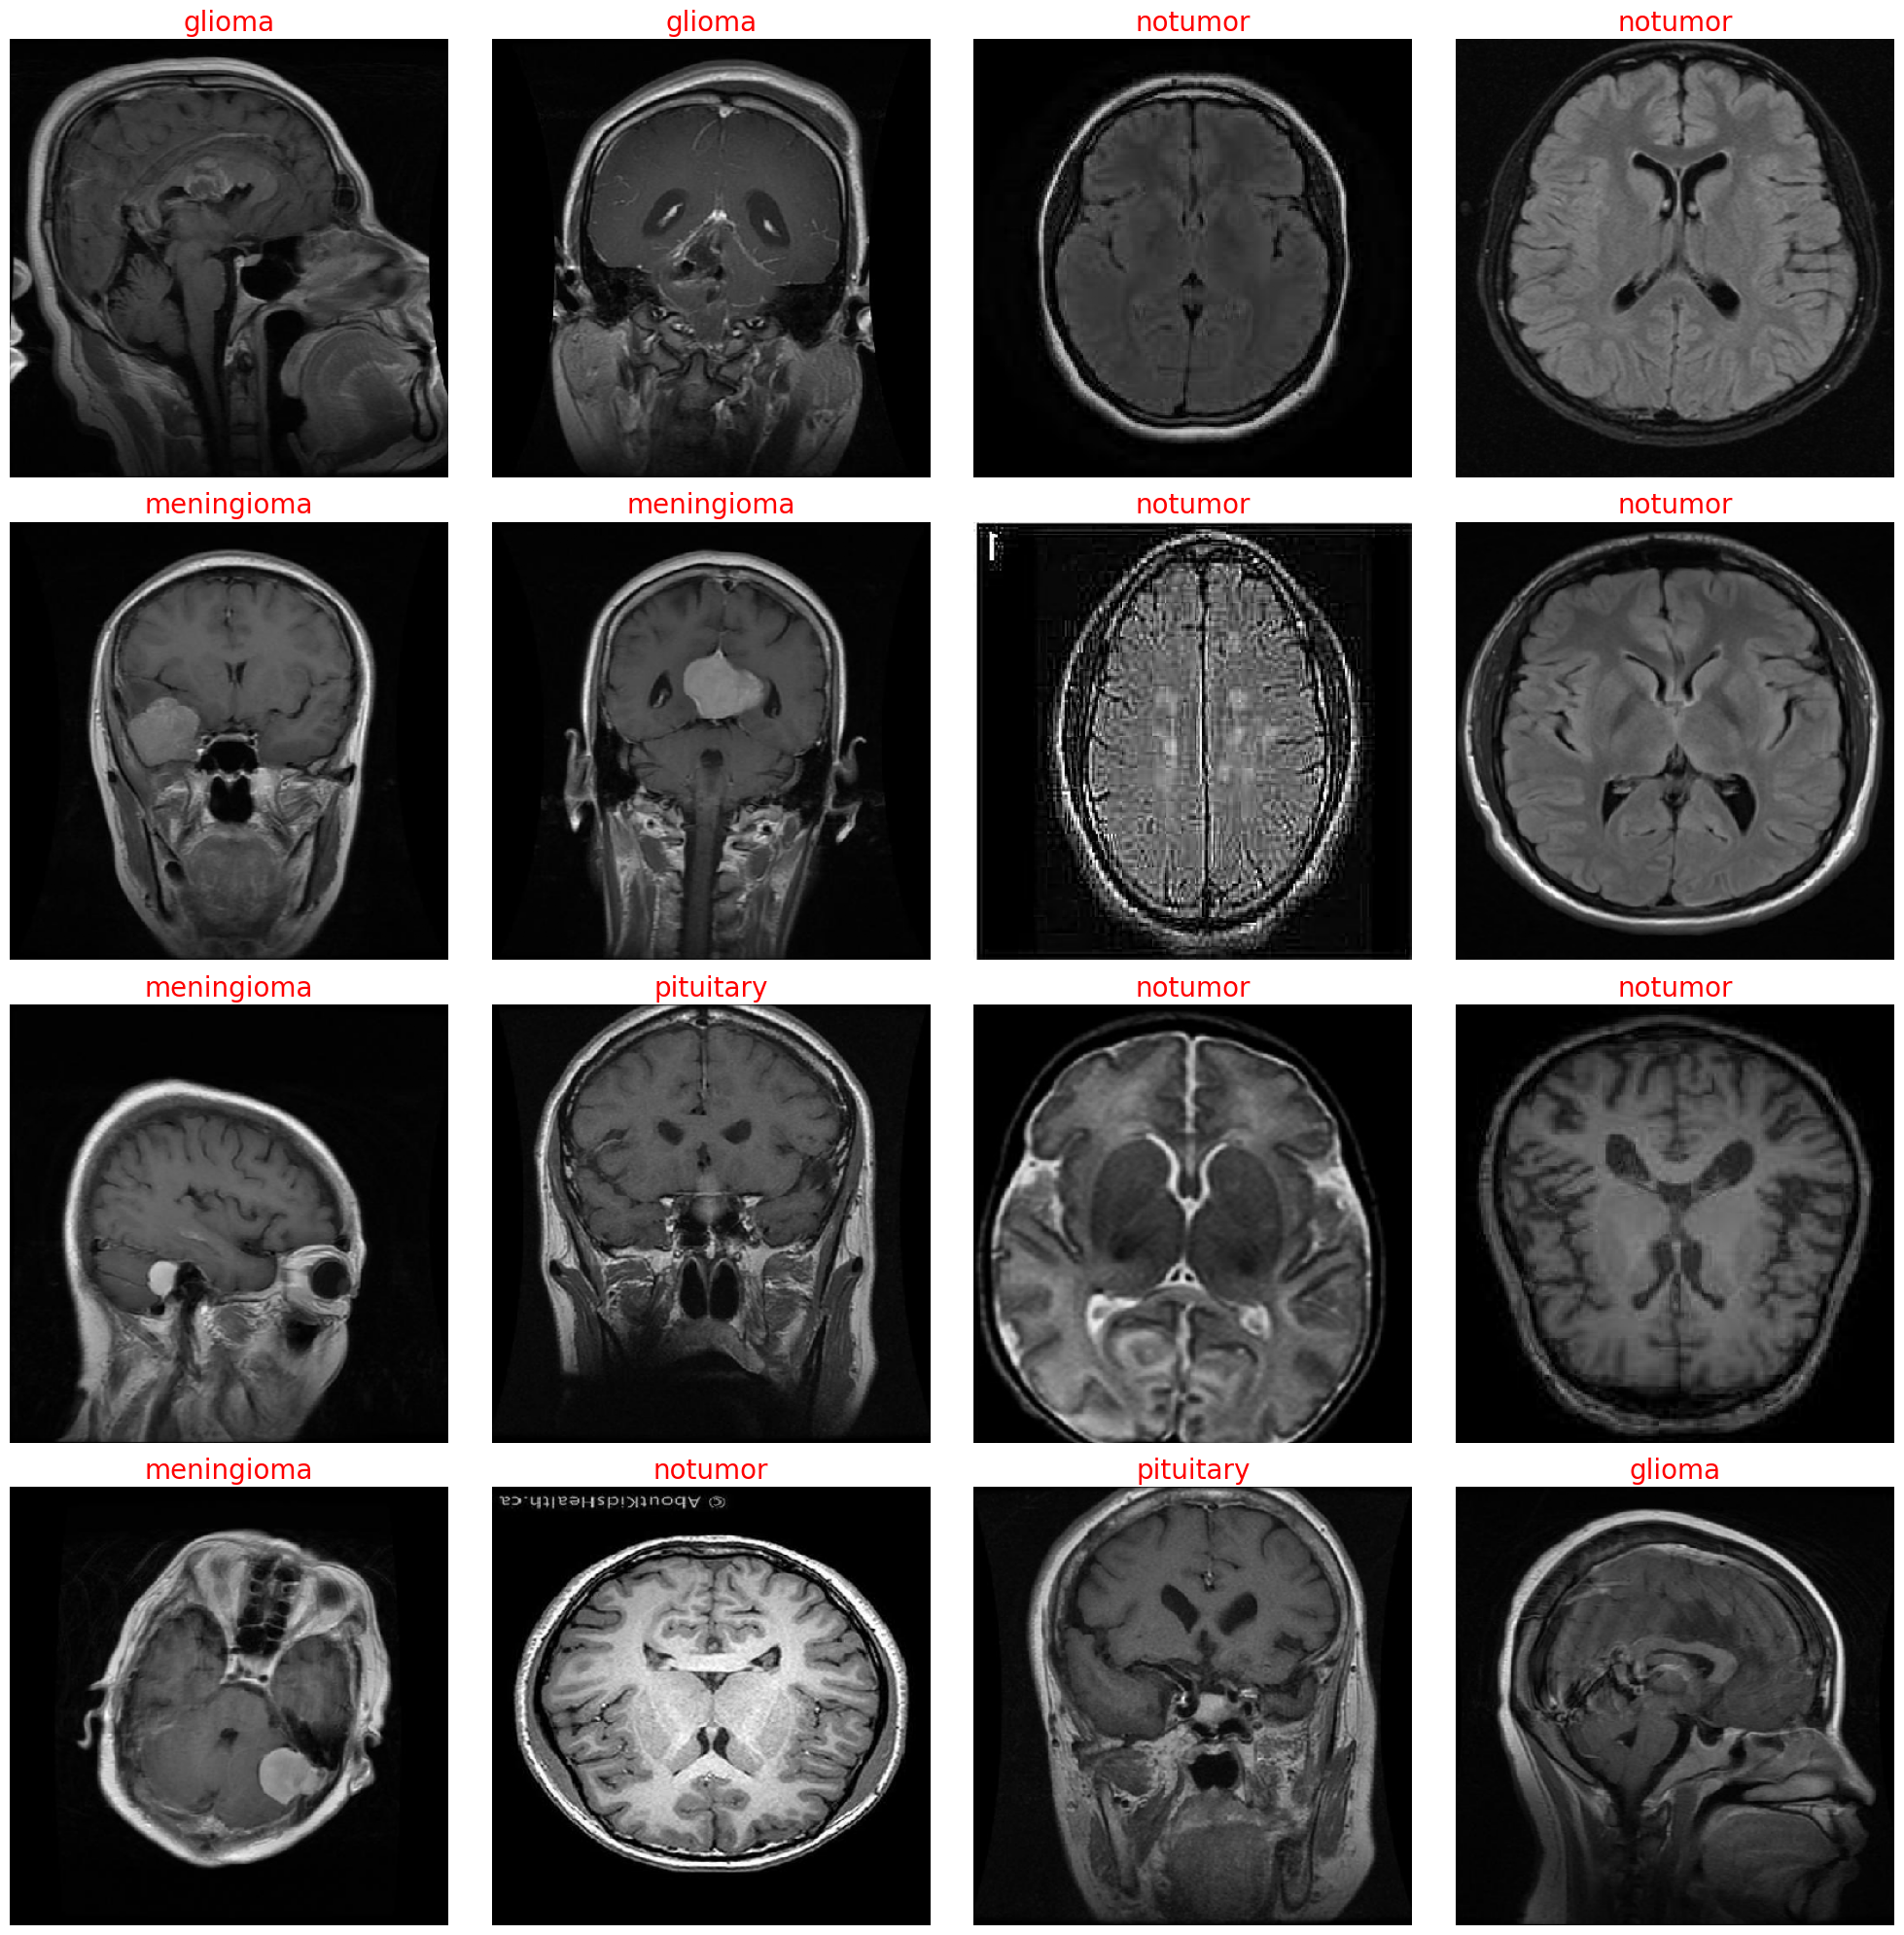

In [12]:
gen_dict = train_generator.class_indices
classes = list(gen_dict.keys())

images, labels = next(train_generator)

plt.figure(figsize=(20, 20))

for i in range(16):
    plt.subplot(4, 4, i + 1)

    image = images[i] / 255.0

    # Display the image
    plt.imshow(image , cmap='gray')

    index = np.argmax(labels[i])
    class_name = classes[index]

    plt.title(class_name, color='red', fontsize=20)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
img_shape = (img_size[0], img_size[1] ,3)
class_count = len(list(train_generator.class_indices.keys()))

strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    base_model = keras.applications.EfficientNetB4(
        include_top=False,
        weights="imagenet",
        input_shape=(380, 380, 3),
        pooling='max',
    )
    base_model.trainable = False

    model = Sequential([
        base_model,
        BatchNormalization(),
        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),
        Dense(4, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb4 (Functional)     │ (None, 1792)           │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1792)           │         7,168 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       459,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,174,947 (69.33 MB)

 Trainable params: 496,772 (1.90 MB)

 Non-trainable params: 17,678,175 (67.44 MB)

In [14]:
print("🔓 Phase : Transfer Learning with freeze weights")

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)


reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=40,
    verbose=1,
    validation_data=valid_generator,
    shuffle=False,
    callbacks=[early_stopping , reduce_lr]
)

🔓 Phase : Transfer Learning with freeze weights
Epoch 1/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 138s 351ms/step - accuracy: 0.7807 - loss: 0.6096 - val_accuracy: 0.8600 - val_loss: 0.4363 - learning_rate: 0.0010
Epoch 2/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 115s 329ms/step - accuracy: 0.8646 - loss: 0.3843 - val_accuracy: 0.8825 - val_loss: 0.4071 - learning_rate: 0.0010
Epoch 3/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 116s 332ms/step - accuracy: 0.8916 - loss: 0.2951 - val_accuracy: 0.9075 - val_loss: 0.3314 - learning_rate: 0.0010
Epoch 4/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 118s 336ms/step - accuracy: 0.9014 - loss: 0.2655 - val_accuracy: 0.9100 - val_loss: 0.3421 - learning_rate: 0.0010
Epoch 5/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 117s 335ms/step - accuracy: 0.9111 - loss: 0.2378 - val_accuracy: 0.9125 - val_loss: 0.3600 - learning_rate: 0.0010
Epoch 6/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.9142 - loss: 0.2336
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
350/350

In [15]:
print("🔓 Phase 2: Fine-tuning entire model")

with strategy.scope():
    base_model.trainable = True  # Unfreeze EfficientNet

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

early_stopping_phase2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_phase2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

history_phase2 = model.fit(
    train_generator,
    epochs=40,
    validation_data=valid_generator,
    shuffle=False,
    callbacks=[early_stopping_phase2, reduce_lr_phase2]
)

🔓 Phase 2: Fine-tuning entire model
Epoch 1/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 502s 1s/step - accuracy: 0.8689 - loss: 0.4226 - val_accuracy: 0.8662 - val_loss: 0.5284 - learning_rate: 1.0000e-04
Epoch 2/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 458s 1s/step - accuracy: 0.9461 - loss: 0.1520 - val_accuracy: 0.9425 - val_loss: 0.3117 - learning_rate: 1.0000e-04
Epoch 3/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 459s 1s/step - accuracy: 0.9630 - loss: 0.1007 - val_accuracy: 0.9513 - val_loss: 0.3108 - learning_rate: 1.0000e-04
Epoch 4/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 464s 1s/step - accuracy: 0.9782 - loss: 0.0615 - val_accuracy: 0.9500 - val_loss: 0.3449 - learning_rate: 1.0000e-04
Epoch 5/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 458s 1s/step - accuracy: 0.9852 - loss: 0.0491 - val_accuracy: 0.9550 - val_loss: 0.2869 - learning_rate: 1.0000e-04
Epoch 6/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 460s 1s/step - accuracy: 0.9839 - loss: 0.0467 - val_accuracy: 0.9550 - val_loss: 0.2921 - learning_rate: 1.0000e-04
Epoch 7/40
350/350 ━━━

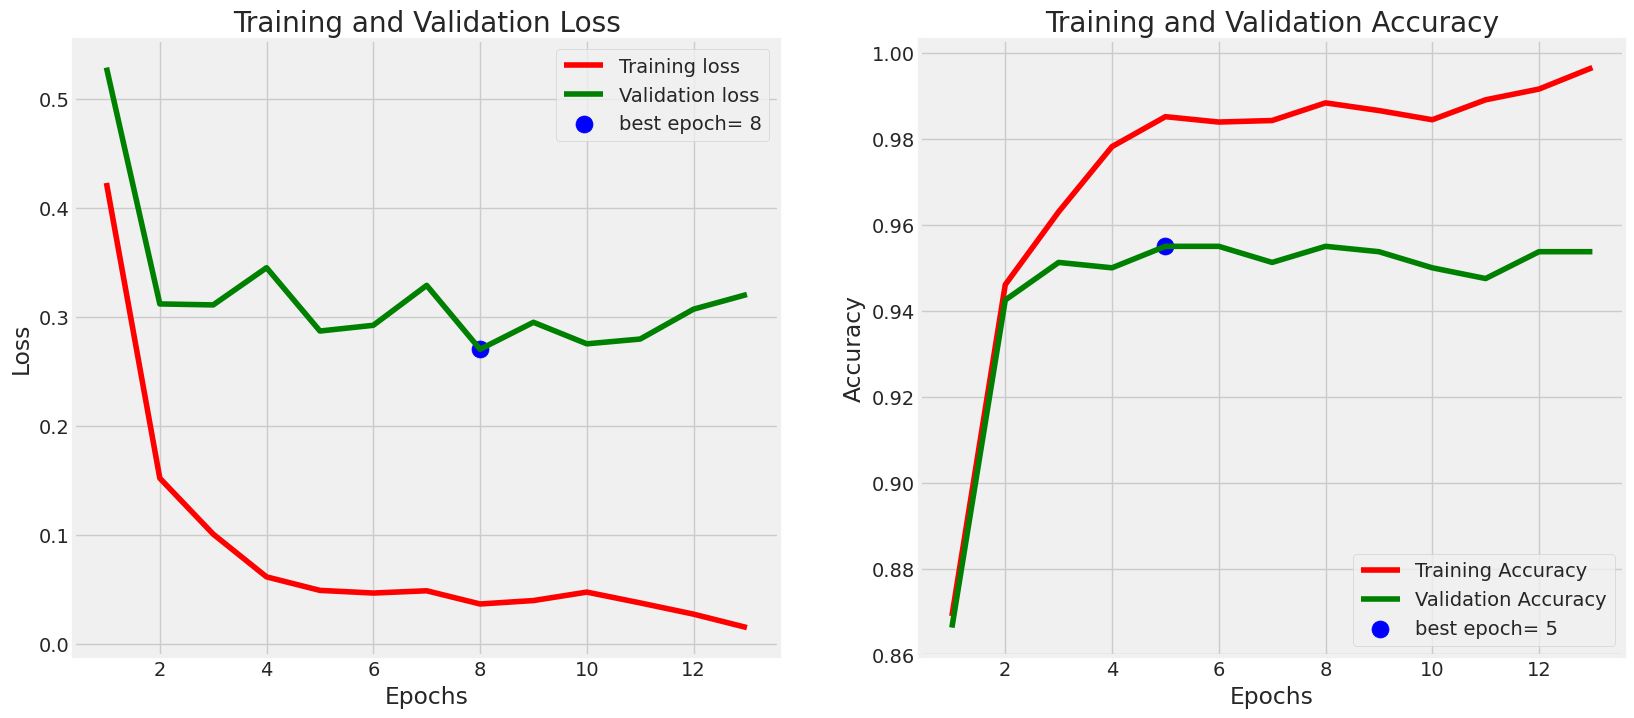

In [16]:
# Define needed variables
tr_acc = history_phase2.history['accuracy']
tr_loss = history_phase2.history['loss']
val_acc = history_phase2.history['val_accuracy']
val_loss = history_phase2.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [17]:
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 279ms/step - accuracy: 0.9500 - loss: 0.2381
Test Accuracy: 95.00%
Test Loss: 0.2381


50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 283ms/step


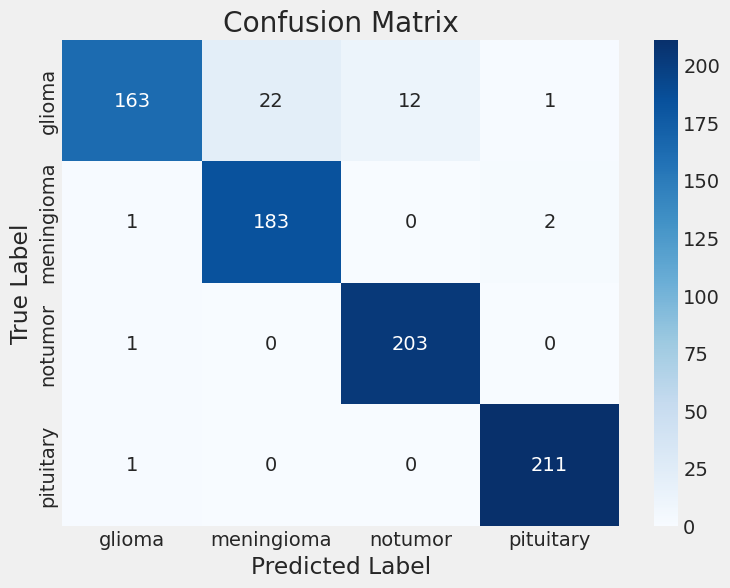

              precision    recall  f1-score   support

      glioma       0.98      0.82      0.90       198
  meningioma       0.89      0.98      0.94       186
     notumor       0.94      1.00      0.97       204
   pituitary       0.99      1.00      0.99       212

    accuracy                           0.95       800
   macro avg       0.95      0.95      0.95       800
weighted avg       0.95      0.95      0.95       800



In [18]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes


class_names = list(test_generator.class_indices.keys())


cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=class_names))

In [20]:
model.save('EfficientNet_best_Model.keras')
print("Saved model")

Saved model
